# Corr_2PCF: Isotropic and Anisotropic Two-Point Statistics

This notebook shows how PyHermes measures the two-point correlation function from `ConvolsData`. We start with isotropic `xi(s)`, then move to anisotropic `xi(s, mu)` and `xi(rp, pi)`, including explicit real-space versus redshift-space comparisons.

## Core Idea

PyHermes turns pair counting into windowed field products. Data and random terms such as `dd`, `dr`, `rd`, and `rr` are combined into `xi`, while the `pair_window` determines which separation or angular geometry is being measured.

This notebook focuses on what is specific to `Corr_2PCF`:

- choosing a `sampling` grid;
- choosing a `pair_window` that maps sampling coordinates to pair-bin geometry;
- optionally applying ordinary smoothing windows through `window`, `window1`, or `window2`;
- reading, checking, and plotting the result.

For ordinary smoothing-window construction and `WindowFunc` algebra, see `window.ipynb` first.


In [1]:
import numpy as np
from numba import njit
import copy
import matplotlib.pyplot as plt

from pyhermes.io import Corr2PCFData
from pyhermes.param.parambase import read_param
from pyhermes.theory.corr2pcf import Corr_2PCF
from pyhermes.utils.plot import plot_corr2pcf_2d
from pyhermes.utils.window_functions import (
    window_function_cylshell_numba,
    window_function_disk_numba,
    window_function_sphere_numba,
)

from pathlib import Path
import os
os.chdir(Path.cwd().resolve().parent)
print(f"Working directory: {Path.cwd()}")

Working directory: /Users/xutengpeng/xutp/PycharmProjects/PyHermes/examples


## 1. The 2PCF Objects

`Corr_2PCF` combines three ideas:

- **field inputs**: `convols_data`, or separate `convols_data1` and `convols_data2`;
- **random inputs**: `random`, or separate `random1` and `random2`; use `"uniform"` for the uniform-density shortcut;
- **pair bins**: `pair_window` plus `sampling`.

The `pair_window` is different from an ordinary smoothing window. It selects the pair separation bin used inside the estimator.

### Minimal YAML Shapes

For an isotropic `xi(s)`, use a shell pair window and sample only `s`:

```yaml
Corr_2PCF:
   convols_data: "./output/quijote8000_snap004_sfc.pkl"
   random: "uniform"
   pair_window: "shell"
   sampling:
      s: {min: 0.0, max: 150.0, n: 31}
   products: "xi"
```

For `xi(s, mu)`, use a line-of-sight pair window such as `ring`, `disk`, `cylshell`, or `cylinder`:

```yaml
Corr_2PCF:
   convols_data: "./output/quijote8000_snap004_sfc.pkl"
   random: "uniform"
   pair_window: "ring"
   sampling:
      s:  {min: 0.0, max: 150.0, n: 30}
      mu: {min: 0.0, max: 1.0,   n: 20}
   products: "xi"
```

For `xi(rp, pi)`, use the same kind of pair window but change the mapping:

```yaml
Corr_2PCF:
   pair_window:
      type: "ring"
      mapping: "rppi_to_RH"
   sampling:
      rp: {min: 0.0, max: 150.0, n: 30}
      pi: {min: 0.0, max: 150.0, n: 30}
```

## 2. Isotropic `xi(s)`

The standard route is to run the script from a YAML config. The command below writes `./output/quijote8000_snap004_2pcf.pkl`.

In [2]:
! mpirun -np 4 python ./scripts/run_2pcf.py ./configs/param_2pcf.yaml

00:41:14 - INFO - pyhermes.param.parambase:ParamBase - Reading configure file: './configs/param_2pcf.yaml'
00:41:14 - INFO - pyhermes.param.parambase:ParamBase - Input parameter file format is YAML
00:41:14 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...
00:41:14 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.convols_data' from 'empty' to './output/quijote8000_snap004_sfc.pkl'
00:41:14 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.random' from 'None' to 'uniform'
00:41:14 - INFO - pyhermes.param.parambase:ParamBase - Using user-provided replacement value for 'Corr_2PCF.pair_window'.
00:41:14 - INFO - pyhermes.param.parambase:ParamBase - Using user-provided replacement value for 'Corr_2PCF.sampling'.
00:41:14 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.products' from 'xi' to '['dd', 'dr', 'rd', 'xi']'
00:41:14 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.threads' fro

Read the saved result. If the config saved pair counts as well as `xi`, the Landy-Szalay combination can be checked explicitly.

00:41:31 - INFO - pyhermes.io.base:Corr2PCFData - Reading 2PCF data from ---> output/quijote8000_snap004_2pcf.pkl <---
00:41:31 - INFO - pyhermes.io.base:Corr2PCFData - s: Num = 31, Min = 0, Max = 150
00:41:31 - INFO - pyhermes.io.base:Corr2PCFData - Products loaded: ['dd', 'dr', 'rd', 'delta_dd', 'rr', 'xi']


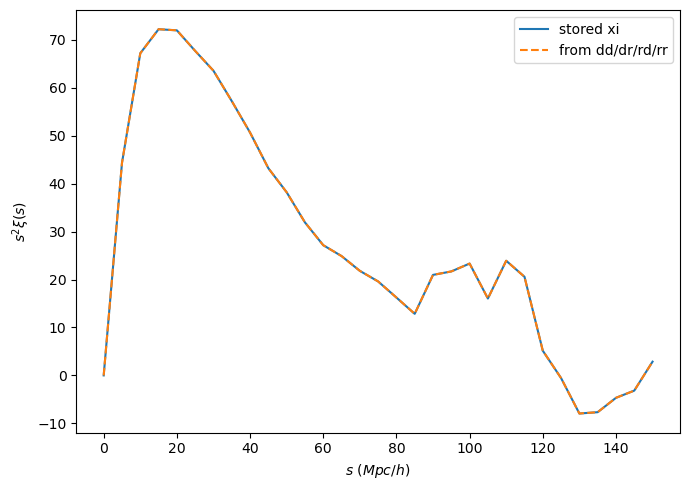

In [3]:
path = Path("./output/quijote8000_snap004_2pcf.pkl")
if path.exists():
    corr_s = Corr2PCFData(data_path=str(path))

    plt.figure(figsize=(7, 5))
    plt.plot(corr_s.s, corr_s.s**2 * corr_s.xi, label="stored xi")

    if all(getattr(corr_s, name, None) is not None for name in ("dd", "dr", "rd", "rr")):
        xi_landy_szalay = (corr_s.dd - corr_s.dr - corr_s.rd + corr_s.rr) / corr_s.rr
        plt.plot(corr_s.s, corr_s.s**2 * xi_landy_szalay, "--", label="from dd/dr/rd/rr")

    plt.xlabel(r"$s\ (Mpc/h)$")
    plt.ylabel(r"$s^2\xi(s)$")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print(f"Missing {path}. Run the command above first.")

The same config can be run in Python. This is useful when you want to override a few values without editing the YAML file.

In [4]:
params = read_param("./configs/param_2pcf.yaml")
task = Corr_2PCF(param_task=params)
task.products = "xi"
task.threads = 8
corr_s = task.run(save_result=False)

00:41:32 - INFO - pyhermes.param.parambase:ParamBase - Reading configure file: './configs/param_2pcf.yaml'
00:41:32 - INFO - pyhermes.param.parambase:ParamBase - Input parameter file format is YAML
00:41:32 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...
00:41:32 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.convols_data' from 'empty' to './output/quijote8000_snap004_sfc.pkl'
00:41:32 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.random' from 'None' to 'uniform'
00:41:32 - INFO - pyhermes.param.parambase:ParamBase - Using user-provided replacement value for 'Corr_2PCF.pair_window'.
00:41:32 - INFO - pyhermes.param.parambase:ParamBase - Using user-provided replacement value for 'Corr_2PCF.sampling'.
00:41:32 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.products' from 'xi' to '['dd', 'dr', 'rd', 'xi']'
00:41:32 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.threads' fro

You can also build a small task directly. In Python, `sampling` entries may be arrays.

In [5]:
task = Corr_2PCF()
task.convols_data1 = "./output/quijote8000_snap004_sfc_massweight.pkl"
task.convols_data2 = "./output/quijote8000_snap004_sfc_massweight.pkl"
task.random1 = "uniform"
task.random2 = "uniform"
task.pair_window = "shell"
task.sampling["s"] = np.linspace(0.0, 150.0, 31)
task.products = "xi"
task.threads = 8
corr_s_massw = task.run(save_result=False)

00:41:40 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...
00:41:40 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - Corr_2PCF runtime configuration: running on 1 MPI ranks with 8 threads per rank
00:41:40 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - Preparing Corr_2PCF input fields ...
00:41:40 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - Sampling: s: n=31, min=0.0, max=150.0, source=explicit array, threads=8
00:41:40 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - Products: requested=[xi] | computed=[delta_dd, rr] | derived=[xi]
00:41:40 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - Pair window: type=shell | mapping=s_to_R | kernel_mode=octant
00:41:40 - INFO - pyhermes.io.base:ConvolsData - Reading Convols data from ---> ./output/quijote8000_snap004_sfc_massweight.pkl <---
00:41:40 - INFO - pyhermes.io.base:ConvolsData - epsilon: Shape(256, 256, 256), Min = -5.599e-05, Max = 0.0002432, Mean = 5.96e-08, Sum = 1
00:41:40 - INFO - pyherm

## 3. Smoothing Windows in `Corr_2PCF`

Ordinary smoothing windows are not pair windows. They are applied to the input fields before pair products are measured. Use the shared `window` field when both legs should use the same smoothing window, or `window1` and `window2` for separate choices.

In [6]:
params = read_param("./configs/param_2pcf.yaml")
params["Corr_2PCF"]["window"] = {
    "type": "sphere",
    "len_args": {"R": 20.0},
}
params["Corr_2PCF"]["products"] = "xi"

task = Corr_2PCF(param_task=params)
task.threads = 8
corr_s_sph20 = task.run(save_result=False)

00:41:52 - INFO - pyhermes.param.parambase:ParamBase - Reading configure file: './configs/param_2pcf.yaml'
00:41:52 - INFO - pyhermes.param.parambase:ParamBase - Input parameter file format is YAML
00:41:52 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...


00:41:52 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.convols_data' from 'empty' to './output/quijote8000_snap004_sfc.pkl'
00:41:52 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.random' from 'None' to 'uniform'
00:41:52 - INFO - pyhermes.param.parambase:ParamBase - Using user-provided replacement value for 'Corr_2PCF.pair_window'.
00:41:52 - INFO - pyhermes.param.parambase:ParamBase - Using user-provided replacement value for 'Corr_2PCF.sampling'.
00:41:52 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.threads' from '1' to '2'
00:41:52 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.fout_path' from 'empty' to './output/quijote8000_snap004_2pcf.pkl'
00:41:52 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.window.type' from 'empty' to 'sphere'
00:41:52 - WARNING - pyhermes.param.parambase:ParamBase - Adding non-default key: 'Corr_2PCF.window.len_args.R'
00:41:52 - INFO - pyhermes.pipeline.pipeline:

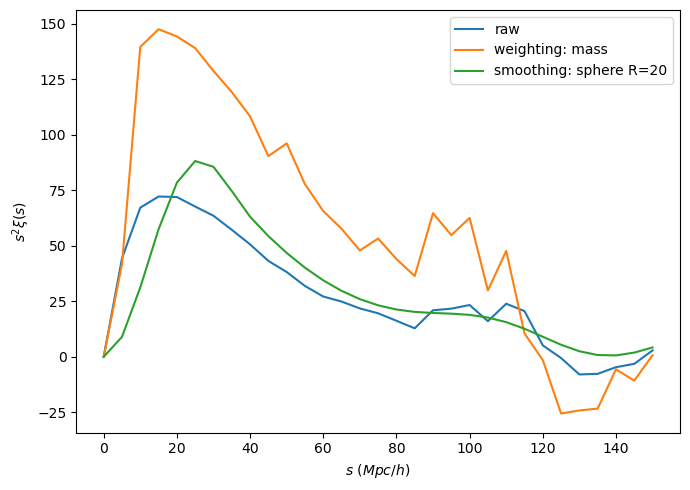

In [7]:
plt.figure(figsize=(7, 5))
plt.plot(corr_s.s, corr_s.s**2 * corr_s.xi, label="raw")
plt.plot(corr_s_massw.s, corr_s_massw.s**2 * corr_s_massw.xi, label="weighting: mass")
plt.plot(corr_s_sph20.s, corr_s_sph20.s**2 * corr_s_sph20.xi, label="smoothing: sphere R=20")
plt.xlabel(r"$s\ (Mpc/h)$")
plt.ylabel(r"$s^2\xi(s)$")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Anisotropic `xi(s, mu)`

The smoke-test config uses a `ring` pair window and a small `(s, mu)` grid.

In [8]:
! mpirun -np 2 python ./scripts/run_2pcf.py ./configs/param_2pcf_smu_test.yaml

00:42:01 - INFO - pyhermes.param.parambase:ParamBase - Reading configure file: './configs/param_2pcf_smu_test.yaml'
00:42:01 - INFO - pyhermes.param.parambase:ParamBase - Input parameter file format is YAML
00:42:01 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...
00:42:01 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.convols_data' from 'empty' to './output/quijote8000_snap004_sfc.pkl'
00:42:01 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.random' from 'None' to 'uniform'
00:42:01 - INFO - pyhermes.param.parambase:ParamBase - Using user-provided replacement value for 'Corr_2PCF.pair_window'.
00:42:01 - INFO - pyhermes.param.parambase:ParamBase - Using user-provided replacement value for 'Corr_2PCF.sampling'.
00:42:01 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.threads' from '1' to '4'
00:42:01 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.fout_path' from 'empty' to '

00:42:14 - INFO - pyhermes.io.base:Corr2PCFData - Reading 2PCF data from ---> output/quijote8000_snap004_2pcf_smu_test.pkl <---
00:42:14 - INFO - pyhermes.io.base:Corr2PCFData - s: Num = 6, Min = 0, Max = 150
00:42:14 - INFO - pyhermes.io.base:Corr2PCFData - mu: Num = 6, Min = 0, Max = 1
00:42:14 - INFO - pyhermes.io.base:Corr2PCFData - Products loaded: ['delta_dd', 'rr', 'xi']


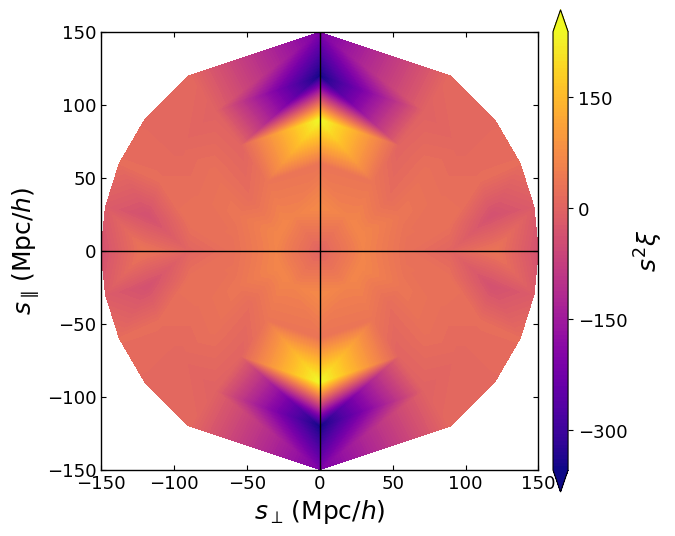

In [9]:
path = Path("./output/quijote8000_snap004_2pcf_smu_test.pkl")
if path.exists():
    corr_smu = Corr2PCFData(data_path=str(path))
    plot_corr2pcf_2d(corr_smu, s_min=0.0)
    plt.tight_layout()
    plt.show()
else:
    print(f"Missing {path}. Run the command above first.")

The same anisotropic estimator can be run on smoothed fields. This changes the ordinary input windows (`window1` and `window2`) while leaving the pair-window geometry fixed. In other words, this cell tests smoothing of the density field, not a change of the pair bin.

In [10]:
params = read_param('./configs/param_2pcf_smu_test.yaml')
task = Corr_2PCF(param_task=params)
task.window1 = {"type": "sphere", "len_args": {"R": 5}}
task.window2 = {"type": "sphere", "len_args": {"R": 5}}
task.threads = 8
corr_smu_sph5 = task.run(save_result=False)

00:42:14 - INFO - pyhermes.param.parambase:ParamBase - Reading configure file: './configs/param_2pcf_smu_test.yaml'
00:42:15 - INFO - pyhermes.param.parambase:ParamBase - Input parameter file format is YAML
00:42:15 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...
00:42:15 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.convols_data' from 'empty' to './output/quijote8000_snap004_sfc.pkl'
00:42:15 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.random' from 'None' to 'uniform'
00:42:15 - INFO - pyhermes.param.parambase:ParamBase - Using user-provided replacement value for 'Corr_2PCF.pair_window'.
00:42:15 - INFO - pyhermes.param.parambase:ParamBase - Using user-provided replacement value for 'Corr_2PCF.sampling'.
00:42:15 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.threads' from '1' to '4'
00:42:15 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.fout_path' from 'empty' to '

Line-of-sight information belongs inside `pair_window.los_args`. With `kernel_mode="auto"`, axis-aligned LOS windows use the fast symmetric path, while oblique LOS windows use the general real-FFT path.

In [11]:
params = read_param("./configs/param_2pcf_smu_test.yaml")
task = Corr_2PCF(param_task=params)
task.pair_window["los_args"] = [1.0, 1.0, 1.0]
task.threads = 8
corr_smu_diag = task.run(save_result=False)

00:42:29 - INFO - pyhermes.param.parambase:ParamBase - Reading configure file: './configs/param_2pcf_smu_test.yaml'
00:42:29 - INFO - pyhermes.param.parambase:ParamBase - Input parameter file format is YAML
00:42:29 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...
00:42:29 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.convols_data' from 'empty' to './output/quijote8000_snap004_sfc.pkl'
00:42:29 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.random' from 'None' to 'uniform'
00:42:29 - INFO - pyhermes.param.parambase:ParamBase - Using user-provided replacement value for 'Corr_2PCF.pair_window'.
00:42:29 - INFO - pyhermes.param.parambase:ParamBase - Using user-provided replacement value for 'Corr_2PCF.sampling'.
00:42:29 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.threads' from '1' to '4'
00:42:29 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.fout_path' from 'empty' to '

Switching from `(s, mu)` to `(rp, pi)` changes the sampling variables and the pair-window mapping, not the field inputs.

In [12]:
params = read_param("./configs/param_2pcf_smu_test.yaml")
task = Corr_2PCF(param_task=params)
task.pair_window["mapping"] = "rppi_to_RH"
task.sampling = {
    "rp": np.linspace(0.0, 150.0, 6),
    "pi": np.linspace(0.0, 150.0, 6),
}
task.threads = 8
corr_rppi = task.run(save_result=False)

00:42:54 - INFO - pyhermes.param.parambase:ParamBase - Reading configure file: './configs/param_2pcf_smu_test.yaml'
00:42:54 - INFO - pyhermes.param.parambase:ParamBase - Input parameter file format is YAML
00:42:54 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...
00:42:54 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.convols_data' from 'empty' to './output/quijote8000_snap004_sfc.pkl'
00:42:54 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.random' from 'None' to 'uniform'
00:42:54 - INFO - pyhermes.param.parambase:ParamBase - Using user-provided replacement value for 'Corr_2PCF.pair_window'.
00:42:54 - INFO - pyhermes.param.parambase:ParamBase - Using user-provided replacement value for 'Corr_2PCF.sampling'.
00:42:54 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.threads' from '1' to '4'
00:42:54 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.fout_path' from 'empty' to '

A quadrant plot is a compact way to compare several coordinate choices or runtime options on the same physical plane. The upper half keeps the `(s, mu)` sampling and changes the line of sight; the lower half compares an `(rp, pi)` sampling and a smoothed-field run. This is a visual API check: the coordinate conversion should put all of them into the same `s_perp`--`s_parallel` picture.

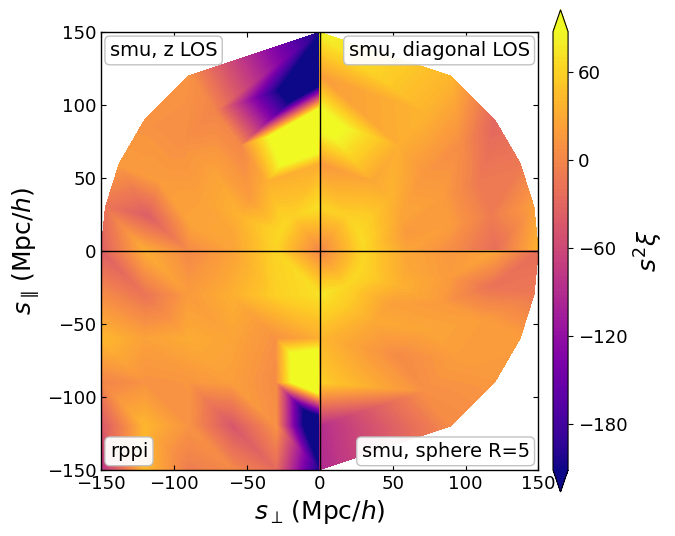

In [13]:
plot_corr2pcf_2d(
    quadrants={
        "upper_left": corr_smu,
        "upper_right": corr_smu_diag,
        "lower_left": corr_rppi,
        "lower_right": corr_smu_sph5,
    },
    quadrant_labels={
        "upper_left": "smu, z LOS",
        "upper_right": "smu, diagonal LOS",
        "lower_left": "rppi",
        "lower_right": "smu, sphere R=5",
    },
    coordinates={
        "upper_left": "smu",
        "upper_right": "smu",
        "lower_left": "rppi",
        "lower_right": "smu",
    },
    s_min=0.0,
)
plt.tight_layout()
plt.show()

## 5. Built-In Pair Windows

For pair windows, string inputs expand to clean defaults:

- `"shell"`: `mapping="s_to_R"`, used for `xi(s)`;
- `"ring"`, `"disk"`, `"cylshell"`, `"cylinder"`: `mapping="smu_to_RH"`, default LOS along z.

Use an explicit dictionary when you want to change the mapping, LOS, or kernel mode.

In [14]:
explicit_disk_pair_window = {
    "type": "disk",
    "len_args": ["R", "H"],
    "los_args": [0.0, 0.0, 1.0],
    "mapping": "smu_to_RH",
    "kernel_mode": "auto",
}

params = read_param("./configs/param_2pcf_smu_test.yaml")
task = Corr_2PCF(param_task=params)
task.pair_window = explicit_disk_pair_window
task.threads = 8
corr_smu_disk = task.run(save_result=False)

00:43:04 - INFO - pyhermes.param.parambase:ParamBase - Reading configure file: './configs/param_2pcf_smu_test.yaml'
00:43:04 - INFO - pyhermes.param.parambase:ParamBase - Input parameter file format is YAML
00:43:04 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...
00:43:04 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.convols_data' from 'empty' to './output/quijote8000_snap004_sfc.pkl'
00:43:04 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.random' from 'None' to 'uniform'
00:43:04 - INFO - pyhermes.param.parambase:ParamBase - Using user-provided replacement value for 'Corr_2PCF.pair_window'.
00:43:04 - INFO - pyhermes.param.parambase:ParamBase - Using user-provided replacement value for 'Corr_2PCF.sampling'.
00:43:04 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.threads' from '1' to '4'
00:43:04 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.fout_path' from 'empty' to '

Here the field, sampling grid, and estimator are kept the same; only the pair window changes from `ring` to `disk`. The `disk` window averages over a transverse disk rather than a thin transverse ring, so differences relative to `ring` should mainly reveal the effect of transverse averaging.

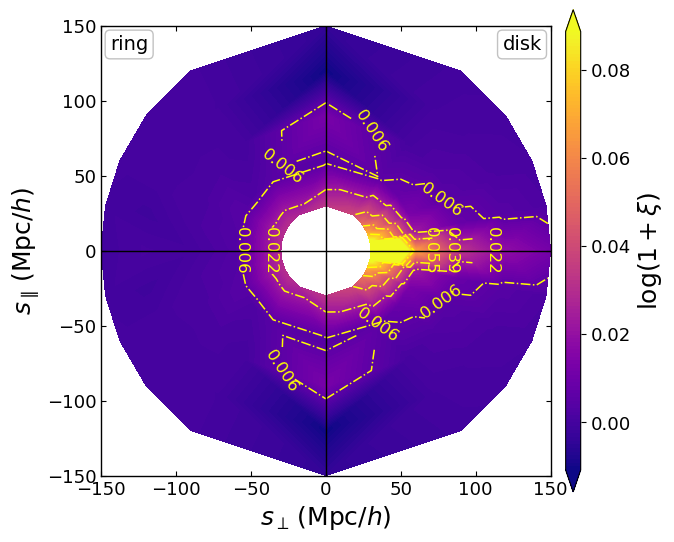

In [15]:
plot_corr2pcf_2d(
    corr_smu,
    corr_smu_disk,
    label1="ring",
    label2="disk",
    value="log10_1p_xi",
    add_contour=True,
    s_min=20.0,
)
plt.tight_layout()
plt.show()

## 6. Custom Pair Window: Minimal Example

A custom pair window is also a Fourier-space kernel. The `mapping` field tells `Corr_2PCF` how to turn one sampling point into the window length arguments.

In [16]:
@njit
def window_function_cosine_numba(ki, kj, kk, R):
    k = np.sqrt(ki * ki + kj * kj + kk * kk)
    q = 2.0 * np.pi * k * R
    return np.cos(q)

cosine_pair_window = {
    "type": "cosine",
    "func": window_function_cosine_numba,
    "len_args": ["R"],
    "mapping": "s_to_R",
    "kernel_mode": "octant",
}

In [17]:
task = Corr_2PCF()
task.convols_data1 = "./output/quijote8000_snap004_sfc.pkl"
task.convols_data2 = "./output/quijote8000_snap004_sfc.pkl"
task.random1 = "uniform"
task.random2 = "uniform"
task.window1 = {"type": "gaussian", "len_args": {"R": 8.0}}
task.window2 = {"type": "gaussian", "len_args": {"R": 8.0}}
task.pair_window = cosine_pair_window
task.sampling["s"] = np.linspace(0.0, 150.0, 31)
task.products = "xi"
task.threads = 8
corr_s_cosine = task.run(save_result=False)

00:43:15 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...
00:43:15 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - Corr_2PCF runtime configuration: running on 1 MPI ranks with 8 threads per rank
00:43:15 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - Preparing Corr_2PCF input fields ...
00:43:15 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - Sampling: s: n=31, min=0.0, max=150.0, source=explicit array, threads=8
00:43:15 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - Products: requested=[xi] | computed=[delta_dd, rr] | derived=[xi]
00:43:15 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - Pair window: type=cosine | mapping=s_to_R | kernel_mode=octant
00:43:15 - INFO - pyhermes.io.base:ConvolsData - Reading Convols data from ---> ./output/quijote8000_snap004_sfc.pkl <---
00:43:15 - INFO - pyhermes.io.base:ConvolsData - epsilon: Shape(256, 256, 256), Min = -3.215e-06, Max = 1.343e-05, Mean = 5.96e-08, Sum = 1
00:43:15 - INFO - pyhermes.pipelin

The cosine pair window is not meant to replace the shell estimator in ordinary analyses. It is a minimal example showing that `Corr_2PCF` only requires a Fourier-space kernel and a mapping from sampling coordinates to kernel arguments.

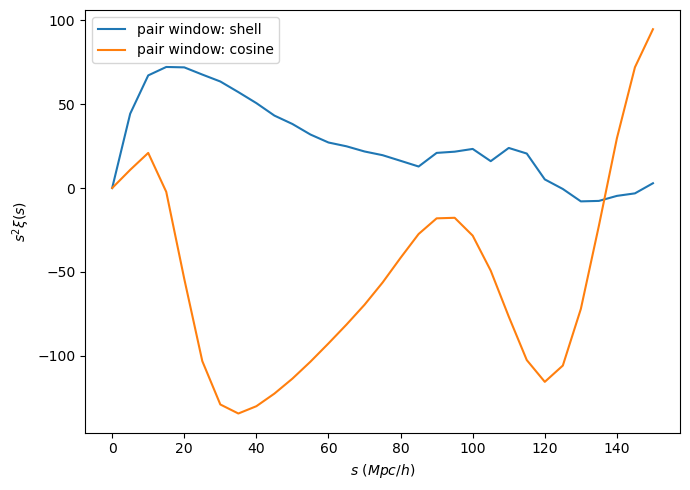

In [18]:
plt.figure(figsize=(7, 5))
plt.plot(corr_s.s, corr_s.s**2 * corr_s.xi, label="pair window: shell")
plt.plot(corr_s_cosine.s, corr_s_cosine.s**2 * corr_s_cosine.xi, label="pair window: cosine")
plt.xlabel(r"$s\ (Mpc/h)$")
plt.ylabel(r"$s^2\xi(s)$")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Custom Mapping: Finite-Thickness Pair Shell

When the sampled coordinate is not identical to a single window length, use a callable mapping. This example maps `s` to an inner and outer radius.

In [19]:
@njit
def window_function_thick_shell_numba(ki, kj, kk, R_in, R_out):
    V_in = R_in**3
    V_out = R_out**3
    denom = V_out - V_in
    if denom == 0.0:
        k = np.sqrt(ki * ki + kj * kj + kk * kk)
        q_out = 2.0 * np.pi * k * R_out
        if q_out == 0.0:
            return 1.0
        return np.sin(q_out) / q_out

    W_in = window_function_sphere_numba(ki, kj, kk, R_in)
    W_out = window_function_sphere_numba(ki, kj, kk, R_out)
    return (W_out * V_out - W_in * V_in) / denom


def mapping_s_to_thick_shell(sample, pair_window, thickness=10.0):
    params = copy.deepcopy(pair_window)
    s = sample["s"]
    params["len_args"]["R_in"] = s - thickness / 2.0
    params["len_args"]["R_out"] = s + thickness / 2.0
    return params

thick_shell_pair_window = {
    "type": "thick_shell",
    "func": window_function_thick_shell_numba,
    "len_args": ["R_in", "R_out"],
    "mapping": mapping_s_to_thick_shell,
    "kernel_mode": "octant",
}

In [20]:
task = Corr_2PCF()
task.convols_data1 = "./output/quijote8000_snap004_sfc.pkl"
task.convols_data2 = "./output/quijote8000_snap004_sfc.pkl"
task.random1 = "uniform"
task.random2 = "uniform"
task.pair_window = thick_shell_pair_window
task.sampling["s"] = np.linspace(5.0, 145.0, 29)
task.products = "xi"
task.threads = 8
corr_s_thick_shell = task.run(save_result=False)

00:43:23 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...
00:43:23 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - Corr_2PCF runtime configuration: running on 1 MPI ranks with 8 threads per rank
00:43:23 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - Preparing Corr_2PCF input fields ...
00:43:23 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - Sampling: s: n=29, min=5.0, max=145.0, source=explicit array, threads=8
00:43:23 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - Products: requested=[xi] | computed=[delta_dd, rr] | derived=[xi]
00:43:23 - INFO - pyhermes.pipeline.pipeline:Corr_2PCF - Pair window: type=thick_shell | mapping=mapping_s_to_thick_shell | kernel_mode=octant
00:43:23 - INFO - pyhermes.io.base:ConvolsData - Reading Convols data from ---> ./output/quijote8000_snap004_sfc.pkl <---
00:43:23 - INFO - pyhermes.io.base:ConvolsData - epsilon: Shape(256, 256, 256), Min = -3.215e-06, Max = 1.343e-05, Mean = 5.96e-08, Sum = 1
00:43:23 - 

This comparison separates two ideas that are easy to conflate. A thick-shell pair window changes the separation bin itself; a smoothing window changes the input field before pair counting. Both can smooth the final curve, but they do so at different points in the estimator.

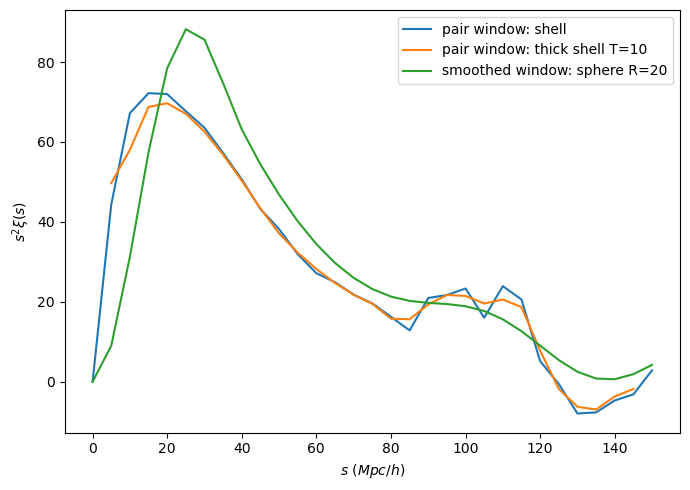

In [21]:
plt.figure(figsize=(7, 5))
plt.plot(corr_s.s, corr_s.s**2 * corr_s.xi, label="pair window: shell")
plt.plot(corr_s_thick_shell.s, corr_s_thick_shell.s**2 * corr_s_thick_shell.xi, label="pair window: thick shell T=10")
plt.plot(corr_s_sph20.s, corr_s_sph20.s**2 * corr_s_sph20.xi, label="smoothed window: sphere R=20")
plt.xlabel(r"$s\ (Mpc/h)$")
plt.ylabel(r"$s^2\xi(s)$")
plt.legend()
plt.tight_layout()
plt.show()

## 8. Compose a Custom Anisotropic Pair Window

This example combines the cylindrical side surface and disk caps into a cylindrical surface. The same definition is used by `examples/scripts/run_2pcf_cylsurf.py` for a production-style run.

In [22]:
@njit
def window_function_cylsurf_numba(ki, kj, kk, R, H, nx=0.0, ny=0.0, nz=1.0):
    denom = 2.0 * H + R
    if denom == 0.0:
        return 1.0
    win_cylshell = window_function_cylshell_numba(ki, kj, kk, R, H, nx, ny, nz)
    win_disk = window_function_disk_numba(ki, kj, kk, R, H, nx, ny, nz)
    return (2.0 * H * win_cylshell + R * win_disk) / denom

cylsurf_pair_window = {
    "type": "cylsurf",
    "func": window_function_cylsurf_numba,
    "len_args": ["R", "H"],
    "los_args": {"nx": 0.0, "ny": 0.0, "nz": 1.0},
    "mapping": "smu_to_RH",
    "kernel_mode": "auto",
}

In [23]:
params = read_param("./configs/param_2pcf_smu_test.yaml")
task = Corr_2PCF(param_task=params)
task.pair_window = cylsurf_pair_window
task.threads = 8
corr_smu_cylsurf = task.run(save_result=False)

00:43:32 - INFO - pyhermes.param.parambase:ParamBase - Reading configure file: './configs/param_2pcf_smu_test.yaml'
00:43:32 - INFO - pyhermes.param.parambase:ParamBase - Input parameter file format is YAML
00:43:32 - INFO - pyhermes.param.parambase:ParamBase - Set default parameters of module <theory> ...
00:43:32 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.convols_data' from 'empty' to './output/quijote8000_snap004_sfc.pkl'
00:43:32 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.random' from 'None' to 'uniform'
00:43:32 - INFO - pyhermes.param.parambase:ParamBase - Using user-provided replacement value for 'Corr_2PCF.pair_window'.
00:43:32 - INFO - pyhermes.param.parambase:ParamBase - Using user-provided replacement value for 'Corr_2PCF.sampling'.
00:43:32 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.threads' from '1' to '4'
00:43:32 - INFO - pyhermes.param.parambase:ParamBase - Default 'Corr_2PCF.fout_path' from 'empty' to '

The `cylsurf` pair window is the area-weighted combination of the cylindrical side surface and disk caps. Comparing it with `disk` helps isolate what is added by the side-surface contribution.

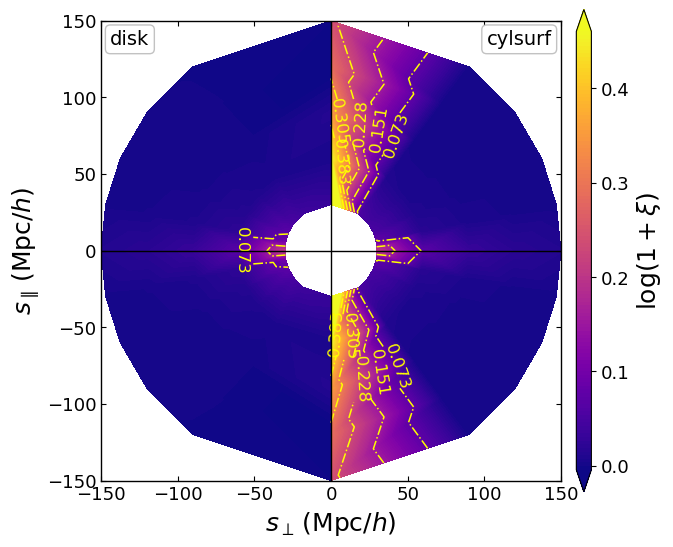

In [24]:
plot_corr2pcf_2d(
    corr_smu_disk,
    corr_smu_cylsurf,
    label1="disk",
    label2="cylsurf",
    value="log10_1p_xi",
    add_contour=True,
    s_min=20.0,
)
plt.tight_layout()
plt.show()

## 9. Optional: Compare Saved Production Outputs

The cells above use small grids so that the notebook stays interactive. The output files below are generated by the scripts and configs in `examples/scripts` and `examples/configs`. If a file is missing, the helper prints the command that creates it and skips the plot.

In [25]:
def load_corr_if_exists(path, command=None):
    path = Path(path)
    if path.exists():
        return Corr2PCFData(data_path=str(path))
    print(f"Missing {path}")
    if command:
        print(f"Create it with: {command}")
    return None

production = {
    "real_smu": load_corr_if_exists(
        "./output/quijote8000_snap004_2pcf_smu.pkl",
        "mpirun -np 4 python ./scripts/run_2pcf.py ./configs/param_2pcf_smu_real.yaml",
    ),
    "rsd_smu": load_corr_if_exists(
        "./output/quijote8000_snap004_rsd_2pcf_smu.pkl",
        "mpirun -np 4 python ./scripts/run_2pcf.py ./configs/param_2pcf_smu.yaml",
    ),
    "rsd_disk": load_corr_if_exists(
        "./output/quijote8000_snap004_rsd_2pcf_smu_disk.pkl",
        "mpirun -np 4 python ./scripts/run_2pcf.py ./configs/param_2pcf_smu_disk.yaml",
    ),
    "rsd_cylshell": load_corr_if_exists(
        "./output/quijote8000_snap004_rsd_2pcf_smu_cylshell.pkl",
        "mpirun -np 4 python ./scripts/run_2pcf.py ./configs/param_2pcf_smu_cylshell.yaml",
    ),
    "rsd_cylsurf": load_corr_if_exists(
        "./output/quijote8000_snap004_rsd_2pcf_smu_cylsurf.pkl",
        "mpirun -np 4 python ./scripts/run_2pcf_cylsurf.py",
    ),
}

00:43:47 - INFO - pyhermes.io.base:Corr2PCFData - Reading 2PCF data from ---> output/quijote8000_snap004_2pcf_smu.pkl <---
00:43:47 - INFO - pyhermes.io.base:Corr2PCFData - s: Num = 46, Min = 0, Max = 180
00:43:47 - INFO - pyhermes.io.base:Corr2PCFData - mu: Num = 51, Min = 0, Max = 1
00:43:47 - INFO - pyhermes.io.base:Corr2PCFData - Products loaded: ['delta_dd', 'rr', 'xi']
00:43:47 - INFO - pyhermes.io.base:Corr2PCFData - Reading 2PCF data from ---> output/quijote8000_snap004_rsd_2pcf_smu.pkl <---
00:43:47 - INFO - pyhermes.io.base:Corr2PCFData - s: Num = 46, Min = 0, Max = 180
00:43:47 - INFO - pyhermes.io.base:Corr2PCFData - mu: Num = 51, Min = 0, Max = 1
00:43:47 - INFO - pyhermes.io.base:Corr2PCFData - Products loaded: ['delta_dd', 'rr', 'xi']
00:43:47 - INFO - pyhermes.io.base:Corr2PCFData - Reading 2PCF data from ---> output/quijote8000_snap004_rsd_2pcf_smu_disk.pkl <---
00:43:47 - INFO - pyhermes.io.base:Corr2PCFData - s: Num = 46, Min = 0, Max = 180
00:43:47 - INFO - pyhermes

The first production comparison holds the pair-window family fixed and changes the input field from real space to redshift space. It is the baseline redshift-space distortion check before comparing different anisotropic pair windows.

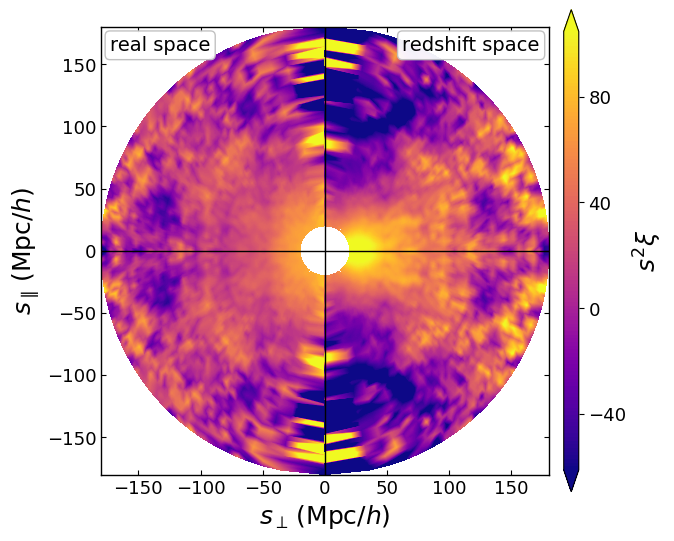

In [26]:
if production["real_smu"] is not None and production["rsd_smu"] is not None:
    plot_corr2pcf_2d(
        production["real_smu"],
        production["rsd_smu"],
        label1="real space",
        label2="redshift space",
        s_min=20.0,
    )
    plt.tight_layout()
    plt.show()

The remaining production plots compare four redshift-space runs with the same input field and the same color scale. Only the anisotropic pair-window geometry changes:

- `ring` is the thin reference window;
- `disk` replaces the thin transverse ring by a finite transverse disk, so it mainly shows transverse averaging;
- `cylshell` replaces the thin line-of-sight offsets by a finite line-of-sight interval, so it mainly shows line-of-sight averaging;
- `cylsurf` combines the disk caps and cylindrical side surface, so it should visually blend the two directional effects.

The next cell gathers these four outputs and fixes a common set of plotting parameters.

In [27]:
corrs_rsd = [production[name] for name in ("rsd_smu", "rsd_disk", "rsd_cylshell", "rsd_cylsurf")]
labels = ["ring", "disk", "cylshell", "cylsurf"]
plot_kwargs = dict(
    s_min=0, add_contour=True, cmap='viridis',
    value='log10_1p_xi', vmin=-0.0005, vmax=0.28,
    contour_levels=[-0.001, 0.003, 0.01, 0.025, 0.05, 0.1, 0.2],
)

The full-panel layout shows each window on its own axes. This is the easiest view for reading morphology: relative to `ring`, `disk` and `cylshell` stretch or smooth the information in different directions, while `cylsurf` looks like the expected merger of those two effects. Because all panels use the same limits and color normalization, these directional changes can be compared directly.

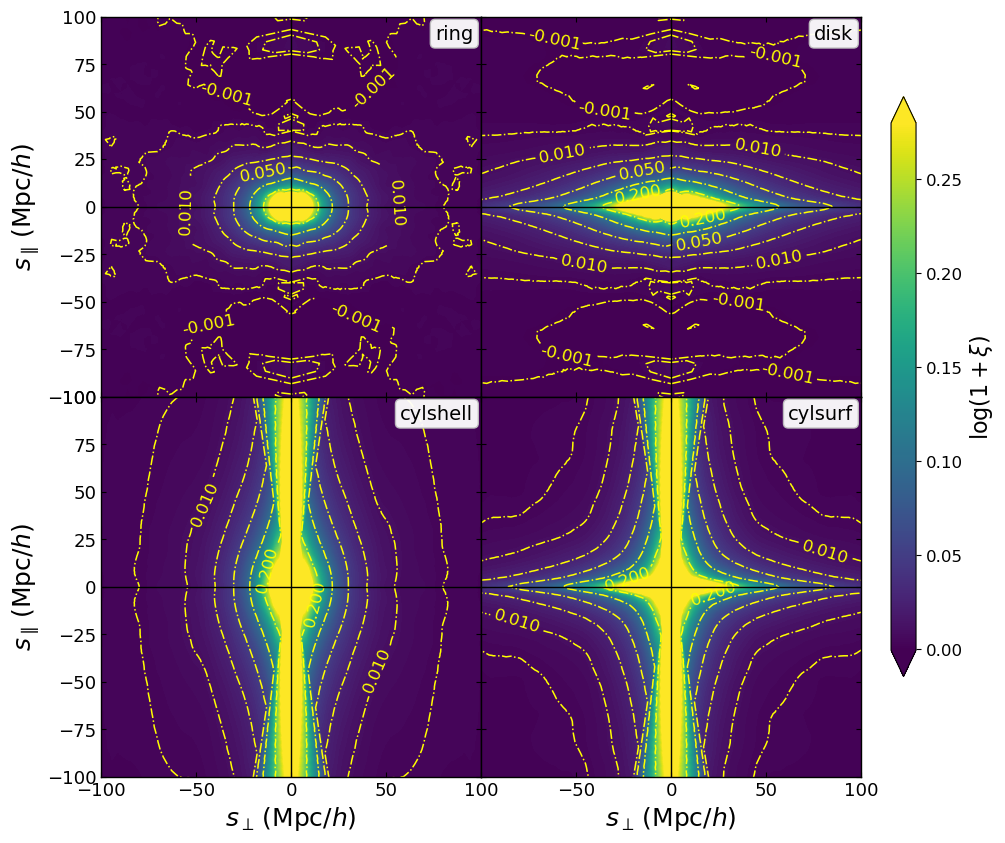

In [28]:
fig, axs = plt.subplots(2, 2, figsize=(10, 10), sharex=True, sharey=True)

fig.subplots_adjust(left=0.08, right=0.84, bottom=0.08, top=0.84, wspace=0, hspace=0)

for i, (ax, corr, label) in enumerate(zip(axs.flat, corrs_rsd, labels)):
    plot_corr2pcf_2d(corr, ax=ax, label1=label, add_colorbar=False, **plot_kwargs)
    ax.set_xlim(-100, 100)
    ax.set_ylim(-100, 100)
    if i // 2 == 0:
        ax.set_xlabel("")
        ax.tick_params(labelbottom=False)
    if i % 2 == 1:
        ax.set_ylabel("")
        ax.tick_params(labelleft=False)
        if xlabels := ax.get_xticklabels():
            xlabels[0].set_visible(False)

import matplotlib
norm = matplotlib.colors.Normalize(vmin=plot_kwargs["vmin"], vmax=plot_kwargs["vmax"])
sm = matplotlib.cm.ScalarMappable(norm=norm, cmap=plot_kwargs["cmap"])
sm.set_array([])
cax = fig.add_axes([0.87, 0.18, 0.025, 0.58])
cbar = fig.colorbar(sm, cax=cax, orientation="vertical", extend="both")
cbar.set_label(r"$\log(1 + \xi)$", fontsize=16)
cbar.ax.tick_params(labelsize=12)

plt.show()


The quadrant layout is a different diagnostic. Instead of emphasizing each panel separately, it stitches four pair-window choices into one plane. The useful thing to inspect is the behavior at the quadrant boundaries: the four windows are different, but their zero-radius and zero-line-of-sight limits should connect smoothly rather than producing artificial seams. Seeing a continuous transition here is a good sanity check on the mapping, normalization, and plotting conversion.

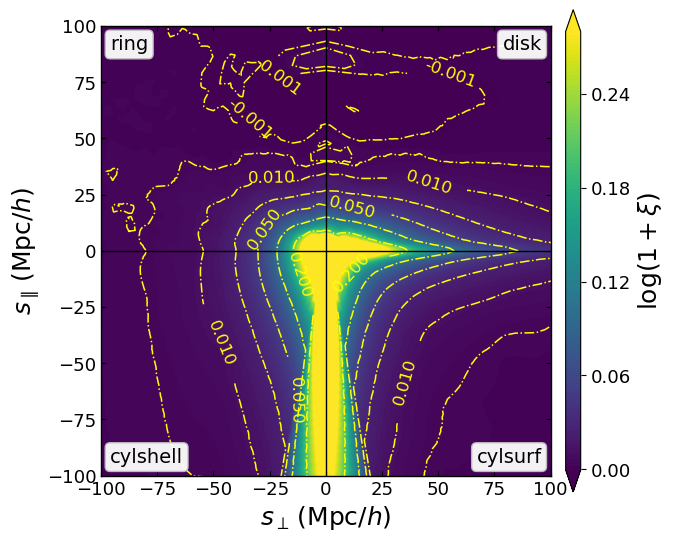

In [29]:
plot_corr2pcf_2d(
    quadrants={
        "upper_left": corrs_rsd[0],
        "upper_right": corrs_rsd[1],
        "lower_left": corrs_rsd[2],
        "lower_right": corrs_rsd[3],
    },
    quadrant_labels={
        "upper_left": labels[0],
        "upper_right": labels[1],
        "lower_left": labels[2],
        "lower_right": labels[3],
    },
    **plot_kwargs
)
plt.xlim(-100, 100)
plt.ylim(-100, 100)
plt.tight_layout()
plt.show()

## 10. Where to Go Next

This notebook treats windows through their 2PCF role as `pair_window` objects. For ordinary smoothing-window construction, `WindowFunc` arithmetic, and custom smoothing filters, see `window.ipynb`.